In [1]:
import pandas, urllib, numpy

In [2]:
import statsmodels, statsmodels.stats, statsmodels.stats.multitest

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
# pip install git+https://github.com/Maayanlab/maayanlab-bioinformatics.git
import maayanlab_bioinformatics, maayanlab_bioinformatics.enrichment

# define library

In [5]:
enrichr_library = 'Reactome_Pathways_2024'

# read data

In [6]:
df = pandas.read_csv('029 orsay Table DEGs - HOM.tsv', sep='\t')
original = df['Gene name'].values
gene_list_input = [element.upper() for element in original]
print(len(gene_list_input), gene_list_input[:10])

244 ['VTN', 'CCDC3', 'DPYD', 'TCFL5', 'CDK15', 'G530011O06RIKY', 'FAM110D', 'SYT15', 'SCRN1', 'VAX2']


In [7]:
def get_library(lib_name):
    '''
    Returns a dictionary mapping each term from the input library to 
    its associated geneset. 
    '''
    raw_lib_data = []

    with urllib.request.urlopen('https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=' + lib_name) as f:
        for line in f.readlines():
            raw_lib_data.append(line.decode("utf-8").split("\t\t"))

    name = []
    gene_list = []
    lib_data = {}

    for i in range(len(raw_lib_data)):
        name += [raw_lib_data[i][0]]
        raw_genes = raw_lib_data[i][1].replace('\t', ' ')
        gene_list += [raw_genes[:-1]]
    
    lib_data = {a[0]:a[1].split(' ') for a in zip(name, gene_list)}
    return lib_data

lib_data = get_library(enrichr_library)

enrich_results = maayanlab_bioinformatics.enrichment.enrich_crisp(gene_list_input, lib_data, 21000, True)

res_df = pandas.DataFrame(
    [ [
        term, 
        res.pvalue, 
        res.odds_ratio,
        res.n_overlap,

    ] for (term, res) in enrich_results ], 
    columns=['term', 'pvalue', 'odds_ratio', 'n_overlap']
)
res_df

,term,pvalue,odds_ratio,n_overlap
0,ADORA2B Mediated Anti-Inflammatory Cytokines P...,0.402357,1.982295,1
1,AMPK Inhibits chREBP Transcriptional Activatio...,0.099859,10.672840,1
2,Abacavir ADME,0.110322,9.486511,1
3,Activated NOTCH1 Transmits Signal to the Nucleus,0.312205,2.751228,1
4,Activation of BAD and Translocation to Mitocho...,0.170606,5.690261,1
...,...,...,...,...
501,Xenobiotics,0.253489,3.554870,1
502,mRNA Splicing,0.920936,0.393167,1
503,mRNA Splicing - Major Pathway,0.909972,0.414589,1
504,p38MAPK Events,0.150978,6.566318,1


In [8]:
# add gene names
container = []
for pathway in res_df['term']:
    
    overlap_genes = []
    for query in lib_data[pathway]:
        if query in gene_list_input:
            overlap_genes.append(query)
    mouse_overlap_genes = [element.lower().title() for element in overlap_genes]
    overlap_genes_string = ', '.join(mouse_overlap_genes)
    container.append(overlap_genes_string)

res_df.loc[:, 'overlap_genes'] = container
res_df

,term,pvalue,odds_ratio,n_overlap,overlap_genes
0,ADORA2B Mediated Anti-Inflammatory Cytokines P...,0.402357,1.982295,1,Adcy1
1,AMPK Inhibits chREBP Transcriptional Activatio...,0.099859,10.672840,1,Adipoq
2,Abacavir ADME,0.110322,9.486511,1,Pck1
3,Activated NOTCH1 Transmits Signal to the Nucleus,0.312205,2.751228,1,Dlk1
4,Activation of BAD and Translocation to Mitocho...,0.170606,5.690261,1,Sfn
...,...,...,...,...,...
501,Xenobiotics,0.253489,3.554870,1,Cyp2E1
502,mRNA Splicing,0.920936,0.393167,1,Snrpn
503,mRNA Splicing - Major Pathway,0.909972,0.414589,1,Snrpn
504,p38MAPK Events,0.150978,6.566318,1,Mapk13


In [9]:
# multiple test correction
results = statsmodels.stats.multitest.multipletests(res_df['pvalue'], alpha=0.05, method='fdr_bh')
res_df['adjusted'] = results[1]

(489, 6)
(17, 6)
1	1.0973938896130357	Formation of the Cornified Envelope	2.504664153562426e-14
2	1.0067301775545852	Immune System	0.0010684851173562084
3	1.0033395412626502	Metal Sequestration by Antimicrobial Proteins	0.0027718225855164016
4	0.8575615684539801	Keratinization	3.0475192762987356e-11
5	0.7375205945137839	Developmental Biology	0.0008995305684662062
6	0.6703913678386401	Type I Hemidesmosome Assembly	0.0008279083805883993
7	0.6480730220696014	Innate Immune System	0.0008995305684662062
8	0.5735740906940121	Neutrophil Degranulation	1.7667037089005674e-06
9	0.42670324450591707	Apoptotic Cleavage of Cell Adhesion Proteins	0.011400970546153076
10	0.24343512570891107	Extracellular Matrix Organization	0.0027718225855164016


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_2668/498813601.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.loc[:, 'importance'] = importance


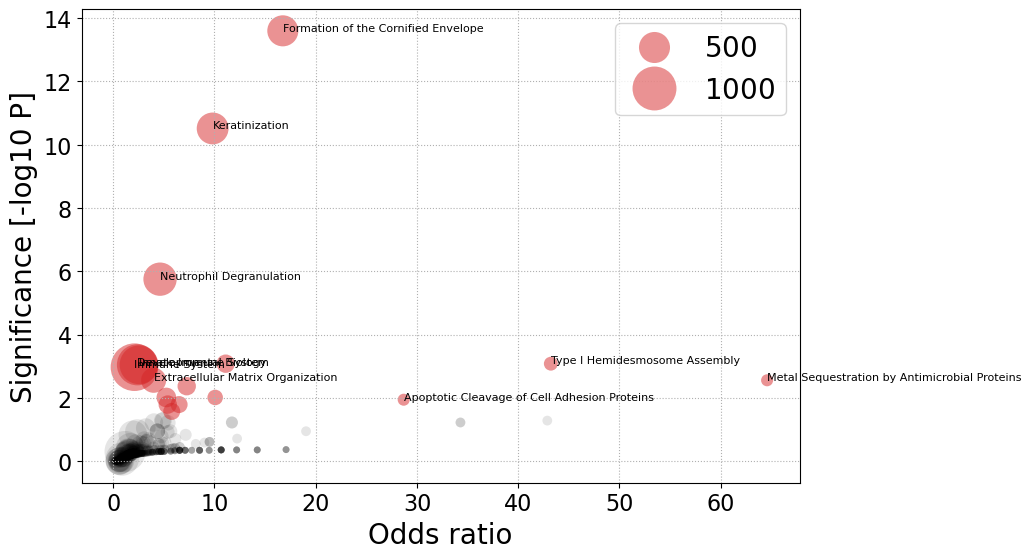

In [15]:
# plot

def importance_calculator(x, y, w):

    xnorm = (x - numpy.min(x)) / (numpy.max(x) - numpy.min(x))
    ynorm = (y - numpy.min(y)) / (numpy.max(y) - numpy.min(y))
    wnorm = (w - numpy.min(w)) / (numpy.max(w) - numpy.min(w))
    
    importance = [numpy.sqrt(xnorm[i]**2 + ynorm[i]**2 + wnorm[i]**2) for i in range(len(x))]
    return importance

inflation = 25

a = res_df[(res_df['adjusted'] > 0.05) | (res_df['odds_ratio'] < 2)]
print(a.shape)
x = a['odds_ratio']
y = -numpy.log10(a['adjusted'])
s = a['n_overlap']
matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/10, edgecolors='none', color='black')

b = res_df[(res_df['adjusted'] < 0.05) & (res_df['odds_ratio'] > 2)]
print(b.shape)
x = b['odds_ratio']
y = -numpy.log10(b['adjusted'])
s = b['n_overlap']
sc = matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/2, edgecolors='none', color='tab:red')

x = list(b['odds_ratio'])
y = list(-numpy.log10(b['adjusted']))
prez = list(b['term'].values)
z = [element.split()[-1] for element in prez]
importance = importance_calculator(x, y, s.values)
b.loc[:, 'importance'] = importance
c = b.sort_values('importance', ascending=False)

threshold = importance[numpy.argsort(importance)[::-1][10]] # gimme the top 10
com = c[c['importance'] > threshold]
count = 0
for index, row in com.iterrows():
    x = row['odds_ratio']
    y = -numpy.log10(row['adjusted'])
    
    label = ' '.join(row['term'].split()[:2])
    label = row['term']
    matplotlib.pyplot.text(x, y, label, fontsize=8)
    count = count + 1
    print('{}\t{}\t{}\t{}'.format(count, row['importance'], row['term'], row['adjusted']))

matplotlib.pyplot.legend(*sc.legend_elements("sizes", num=3, color='tab:red', alpha=1/2, mew=0))
matplotlib.pyplot.xlabel('Odds ratio')
matplotlib.pyplot.ylabel('Significance [-log10 P]')
matplotlib.pyplot.grid(ls=':', alpha=1)
matplotlib.pyplot.tight_layout()

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('hom.svg')

In [11]:
# store list 
print(c.shape)
c.drop('pvalue', axis='columns', inplace=True)
d = c.iloc[:, [0, 5, 4, 1, 2, 3]]
d.rename(columns={"term": "Term", 
                  "importance": "Priority", 
                  'adjusted':'Adjusted P', 
                  'odds_ratio':'Odds ratio',
                 'n_overlap':'N overlap',
                 'overlap_genes':'Overlap genes'}, inplace=True)
d.set_index('Term', inplace=True)
d.head()
d.to_csv('hom.wikipathways.tsv', sep='\t')

d

(17, 7)


,Priority,Adjusted P,Odds ratio,N overlap,Overlap genes
Term,,,,,
Formation of the Cornified Envelope,1.097394,2.504664e-14,16.758117,20,"Krt5, Pkp3, Dsc3, Pkp1, Krt6A, Perp, Krt6B, Sp..."
Immune System,1.006730,1.068485e-03,2.107200,47,"Siglec1, Pglyrp1, Pkp1, Lcn2, Col17A1, Tnfrsf1..."
Metal Sequestration by Antimicrobial Proteins,1.003340,2.771823e-03,64.580913,3,"Lcn2, S100A9, S100A8"
Keratinization,0.857562,3.047519e-11,9.827662,21,"Krt5, Sprr1A, Krtap8-1, Krt14, Krt19, Krt17, K..."
Developmental Biology,0.737521,8.995306e-04,2.401557,35,"Pkp3, Dsc3, Pkp1, Dsp, Shtn1, Krtap8-1, Ptprc,..."
Type I Hemidesmosome Assembly,0.670391,8.279084e-04,43.225000,4,"Col17A1, Krt5, Krt14, Lamc2"
Innate Immune System,0.648073,8.995306e-04,2.554037,31,"C3, Iqgap2, Arg1, Pglyrp1, Pkp1, S100A9, S100A..."
Neutrophil Degranulation,0.573574,1.766704e-06,4.633048,23,"Retn, Cfd, C3, Iqgap2, Arg1, Pglyrp1, Pkp1, S1..."
Apoptotic Cleavage of Cell Adhesion Proteins,0.426703,1.140097e-02,28.695712,3,"Dsp, Cdh1, Pkp1"
